# Projeto 1 — Análise de Indicadores de Carteira com Dados do BCB
**Autor:** Lucas Abreu


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import time

print('Bibliotecas carregadas!')
print(f'pandas: {pd.__version__}')

Bibliotecas carregadas!
pandas: 2.2.3


In [2]:
def get_bcb_series(codigo_serie, data_inicio, data_fim, nome):
    url = (
        f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo_serie}/dados'
        f'?formato=json&dataInicial={data_inicio}&dataFinal={data_fim}'
    )
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    df = pd.DataFrame(response.json())
    df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')
    df['valor'] = pd.to_numeric(df['valor'].str.replace(',', '.'), errors='coerce')
    df = df.set_index('data').rename(columns={'valor': nome})
    return df


def get_bcb_series_completo(codigo_serie, nome):
    periodos = [
        ('01/01/2010', '31/12/2014'),
        ('01/01/2015', '31/12/2019'),
        ('01/01/2020', '31/12/2024'),
    ]
    partes = []
    for inicio, fim in periodos:
        df_parte = get_bcb_series(codigo_serie, inicio, fim, nome)
        partes.append(df_parte)
        time.sleep(2)
    resultado = pd.concat(partes)
    print(f'  v {nome}: {len(resultado)} registros')
    return resultado


print('Funcoes definidas!')

Funcoes definidas!


In [3]:
SERIES = {
    432:  'SELIC_meta',
    433:  'IPCA_acumulado',
    12:   'SELIC_efetiva',
    4389: 'CDI',
}

print('Coletando dados de 2010 a 2024 (pode demorar ~1 minuto)...')
frames = []
for codigo, nome in SERIES.items():
    print(f'\nColetando {nome}...')
    df_serie = get_bcb_series_completo(codigo, nome)
    frames.append(df_serie)

df = pd.concat(frames, axis=1)
df = df[~df.index.duplicated(keep='first')]
df = df.sort_index()

print(f'\nDataset final: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.tail(3)

Coletando dados de 2010 a 2024 (pode demorar ~1 minuto)...

Coletando SELIC_meta...
  v SELIC_meta: 5479 registros

Coletando IPCA_acumulado...
  v IPCA_acumulado: 180 registros

Coletando SELIC_efetiva...
  v SELIC_efetiva: 3767 registros

Coletando CDI...
  v CDI: 3767 registros

Dataset final: 5479 linhas x 4 colunas


,SELIC_meta,IPCA_acumulado,SELIC_efetiva,CDI
data,,,,
2024-12-29,12.25,NaN,NaN,NaN
2024-12-30,12.25,NaN,0.045513,12.15
2024-12-31,12.25,NaN,0.045513,12.15


In [4]:
print('=== Qualidade dos dados ===')
print(f'Periodo: {df.index.min().date()} a {df.index.max().date()}')
print(f'\nValores nulos por coluna:')
print(df.isnull().sum())
print(f'\nEstatisticas descritivas:')
df.describe().round(2)

=== Qualidade dos dados ===
Periodo: 2010-01-01 a 2024-12-31

Valores nulos por coluna:
SELIC_meta           0
IPCA_acumulado    5299
SELIC_efetiva     1712
CDI               1712
dtype: int64

Estatisticas descritivas:


,SELIC_meta,IPCA_acumulado,SELIC_efetiva,CDI
count,5479.00,180.00,3767.00,3767.00
mean,9.61,0.48,0.04,9.48
std,3.46,0.36,0.01,3.46
min,2.00,-0.68,0.01,1.90
25%,7.00,0.25,0.03,6.89
50%,10.50,0.45,0.04,10.40
75%,12.25,0.71,0.05,12.15
max,14.25,1.62,0.05,14.14


In [10]:
df_mensal = df.resample('ME').last().ffill()
df_mensal['juro_real'] = df_mensal['CDI'] - df_mensal['IPCA_acumulado']
df_mensal['spread_CDI_SELIC'] = df_mensal['CDI'] - df_mensal['SELIC_meta']

print('Indicadores criados!')
df_mensal[['SELIC_meta', 'IPCA_acumulado', 'juro_real']].tail(6)

Indicadores criados!


,SELIC_meta,IPCA_acumulado,juro_real
data,,,
2024-07-31,10.50,0.38,10.02
2024-08-31,10.50,-0.02,10.42
2024-09-30,10.75,0.44,10.21
2024-10-31,10.75,0.56,10.09
2024-11-30,11.25,0.39,10.76
2024-12-31,12.25,0.52,11.63


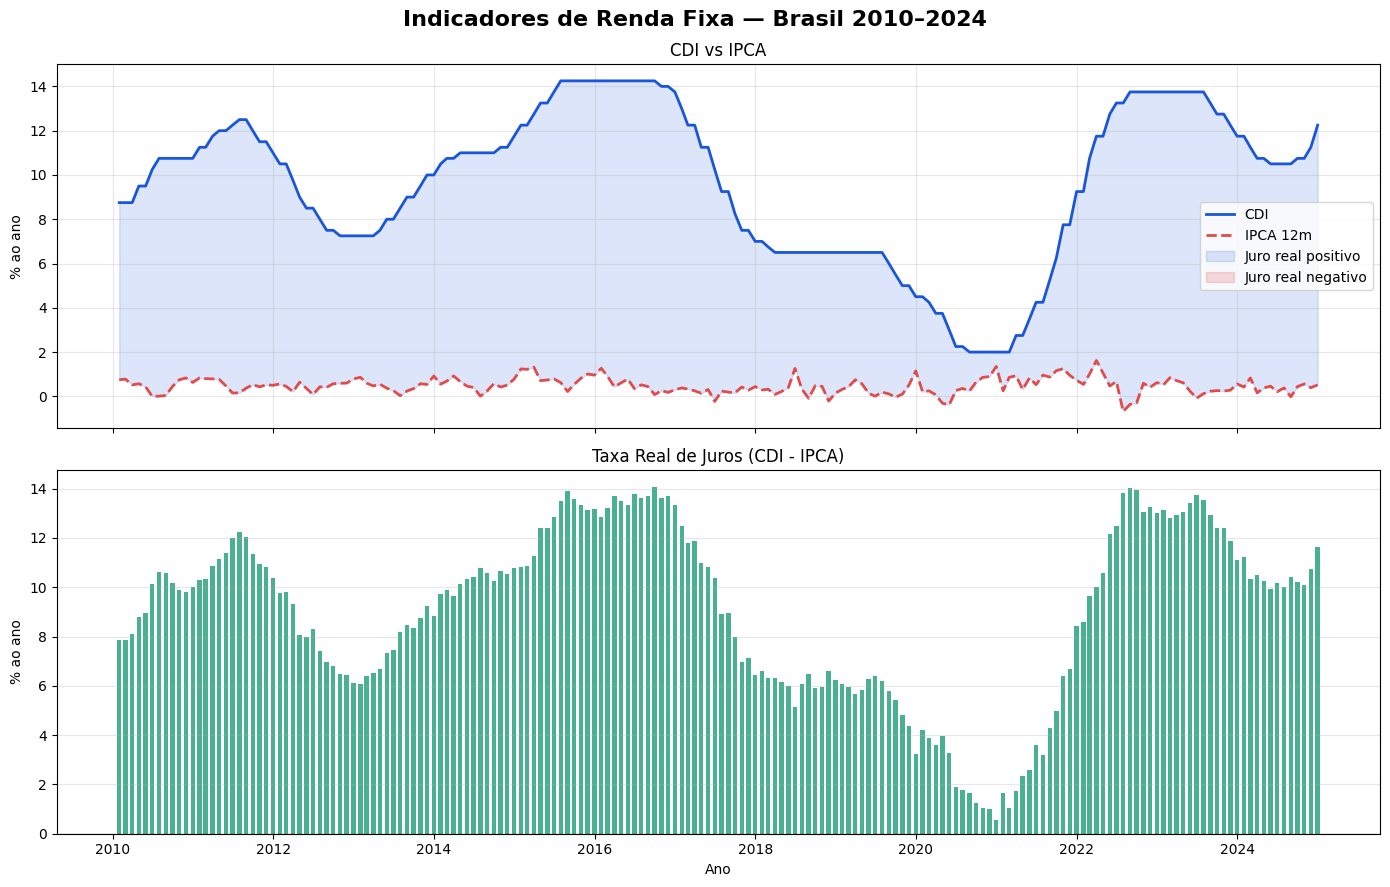

Grafico 1 salvo!


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Indicadores de Renda Fixa — Brasil 2010–2024', fontsize=16, fontweight='bold')

ax1 = axes[0]
ax1.plot(df_mensal.index, df_mensal['SELIC_meta'], label='CDI', color='#1A56DB', linewidth=2)
ax1.plot(df_mensal.index, df_mensal['IPCA_acumulado'], label='IPCA 12m', color='#E24B4A', linewidth=2, linestyle='--')
ax1.fill_between(df_mensal.index, df_mensal['SELIC_meta'], df_mensal['IPCA_acumulado'],
                 where=df_mensal['SELIC_meta'] >= df_mensal['IPCA_acumulado'],
                 alpha=0.15, color='#1A56DB', label='Juro real positivo')
ax1.fill_between(df_mensal.index, df_mensal['SELIC_meta'], df_mensal['IPCA_acumulado'],
                 where=df_mensal['SELIC_meta'] < df_mensal['IPCA_acumulado'],
                 alpha=0.2, color='#E24B4A', label='Juro real negativo')
ax1.set_ylabel('% ao ano')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title('CDI vs IPCA')

ax2 = axes[1]
cores = ['#1D9E75' if v >= 0 else '#E24B4A' for v in df_mensal['juro_real']]
ax2.bar(df_mensal.index, df_mensal['juro_real'], color=cores, alpha=0.8, width=20)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('% ao ano')
ax2.set_xlabel('Ano')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_title('Taxa Real de Juros (CDI - IPCA)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig('grafico1_selic_ipca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico 1 salvo!')

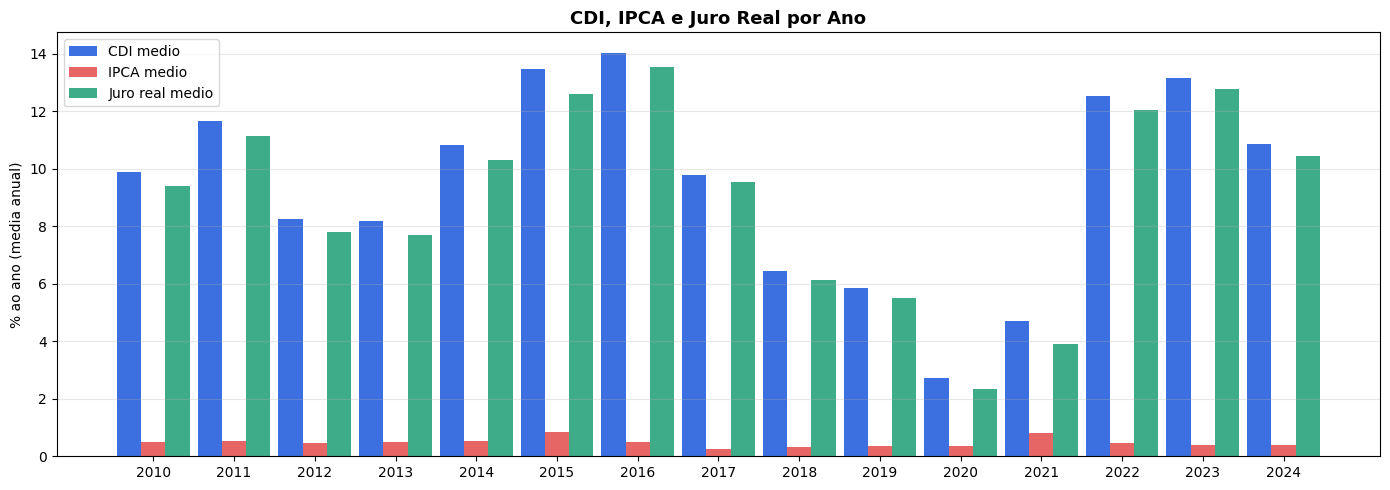

Grafico 2 salvo!


In [22]:
df_anual = df_mensal[['CDI', 'IPCA_acumulado', 'juro_real']].groupby(df_mensal.index.year).mean().round(2)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(df_anual))
width = 0.3
ax.bar([i - width for i in x], df_anual['CDI'], width, label='CDI medio', color='#1A56DB', alpha=0.85)
ax.bar([i for i in x], df_anual['IPCA_acumulado'], width, label='IPCA medio', color='#E24B4A', alpha=0.85)
ax.bar([i + width for i in x], df_anual['juro_real'], width, label='Juro real medio',
       color=['#1D9E75' if v >= 0 else '#E24B4A' for v in df_anual['juro_real']], alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(df_anual.index)
ax.set_ylabel('% ao ano (media anual)')
ax.set_title('CDI, IPCA e Juro Real por Ano', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('grafico2_ciclos_anuais.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico 2 salvo!')

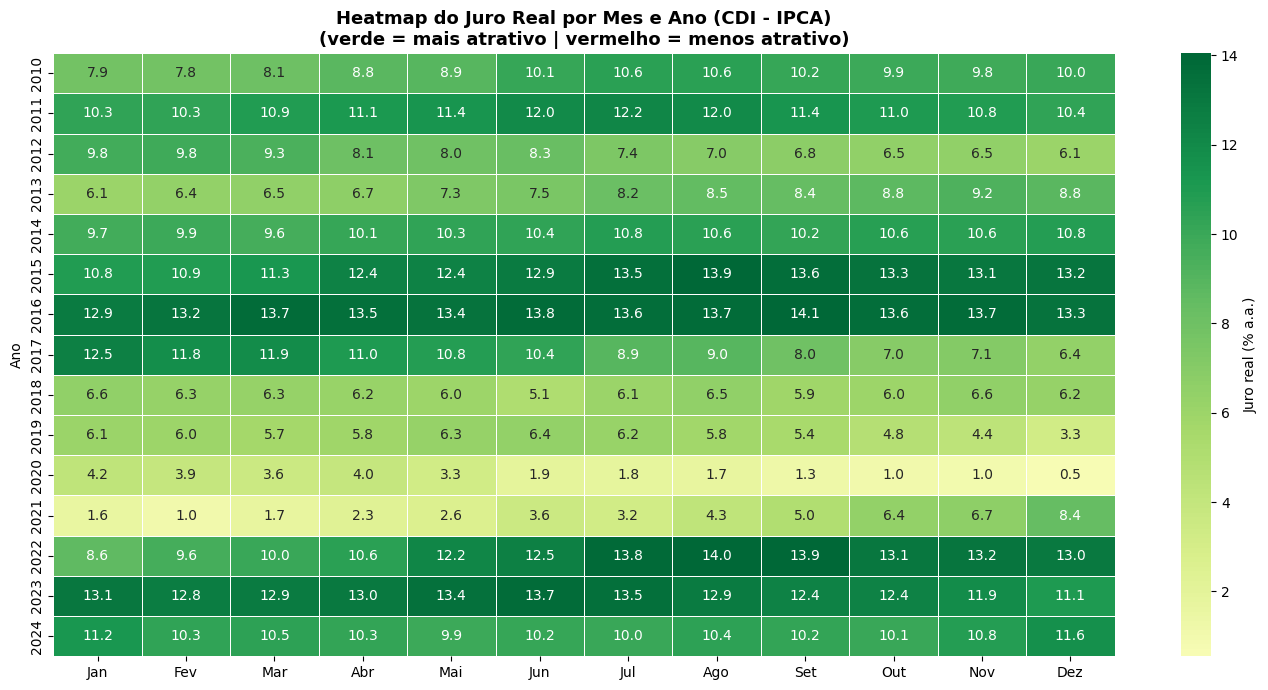

Grafico 3 salvo!


In [23]:
pivot_df = pd.DataFrame({
    'Ano': df_mensal.index.year,
    'Mes': df_mensal.index.month,
    'juro_real': df_mensal['juro_real'].values
})
heatmap_data = pivot_df.pivot(index='Ano', columns='Mes', values='juro_real')
heatmap_data.columns = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(heatmap_data, ax=ax, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
            linewidths=0.4, cbar_kws={'label': 'Juro real (% a.a.)'})
ax.set_title('Heatmap do Juro Real por Mes e Ano (CDI - IPCA)\n(verde = mais atrativo | vermelho = menos atrativo)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Ano')
plt.tight_layout()
plt.savefig('grafico3_heatmap_juro_real.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico 3 salvo!')

In [9]:
top5_melhor = df_mensal[['SELIC_meta', 'IPCA_acumulado', 'juro_real']].nlargest(5, 'juro_real')
top5_pior   = df_mensal[['SELIC_meta', 'IPCA_acumulado', 'juro_real']].nsmallest(5, 'juro_real')

print('=== TOP 5 MELHORES JANELAS PARA RENDA FIXA ===')
print(top5_melhor.round(2).to_string())
print('\n=== TOP 5 PIORES JANELAS ===')
print(top5_pior.round(2).to_string())

pct_positivo = (df_mensal['juro_real'] > 0).mean() * 100
juro_real_medio = df_mensal['juro_real'].mean()

print(f'\n=== RESUMO DO PERIODO ===')
print(f'  Juro real medio:               {juro_real_medio:.2f}% a.a.')
print(f'  % do tempo com juro real > 0:  {pct_positivo:.1f}%')
print(f'  SELIC maxima:                  {df_mensal["SELIC_meta"].max():.2f}%')
print(f'  IPCA maximo:                   {df_mensal["IPCA_acumulado"].max():.2f}%')

=== TOP 5 MELHORES JANELAS PARA RENDA FIXA ===
            SELIC_meta  IPCA_acumulado  juro_real
data                                             
2016-09-30       14.25            0.08      14.17
2022-08-31       13.75           -0.36      14.11
2022-09-30       13.75           -0.29      14.04
2015-08-31       14.25            0.22      14.03
2022-07-31       13.25           -0.68      13.93

=== TOP 5 PIORES JANELAS ===
            SELIC_meta  IPCA_acumulado  juro_real
data                                             
2020-12-31         2.0            1.35       0.65
2020-11-30         2.0            0.89       1.11
2020-10-31         2.0            0.86       1.14
2021-02-28         2.0            0.86       1.14
2020-09-30         2.0            0.64       1.36

=== RESUMO DO PERIODO ===
  Juro real medio:               9.15% a.a.
  % do tempo com juro real > 0:  100.0%
  SELIC maxima:                  14.25%
  IPCA maximo:                   1.62%


## Conclusoes

> **Substitua este bloco com suas proprias conclusoes apos rodar a analise.**

Com base na analise realizada, seguem conclusões:

1. No período analisado, o juro real se manteve positivo em todos os meses do período, indicando que a renda fixa brasileira ofereceu proteção consistente contra a inflação, mesmo em períodos de maior volatilidade no mercado, como greve dos caminhoneiros, impeachment e pandemia.
2. Os períodos de maior atratividade para renda fixa foram 2015–2016, durante a crise política e fiscal, e 2022–2023, no ciclo de alta da SELIC pós-pandemia, com juro real médio acima de 13% a.a."
3. O período de maior compressão do juro real foi 2020–2021, quando o Banco Central reduziu a SELIC para a mínima histórica de 2% a.a. para estimular a economia durante a pandemia. Com o CDI próximo de zero e a inflação começando a acelerar, o juro real chegou a 0,5% a.a. praticamente nulo. Nesse cenário, investidores em produtos pós-fixados convencionais viram seu capital preservado nominalmente, mas com retorno real quase inexistente, o que justificou a migração para ativos de maior risco como fundos multimercado e renda variável naquele período.
4. O heatmap revelou um padrão assimétrico em 2021: o juro real saiu de 1,6% em janeiro e encerrou o ano em 8,4% em dezembro, refletindo o início do ciclo de alta da SELIC pelo Banco Central a partir de março daquele ano. Esse movimento gradual representa uma janela de oportunidade para o investidor que antecipou o ciclo. Quem alocou em prefixados ou títulos IPCA+ no início de 2021 capturou taxas historicamente atrativas antes da correção do mercado
5. A análise evidencia que a estratégia de alocação em renda fixa no Brasil deve acompanhar os ciclos da política monetária. Em períodos de alta da SELIC, produtos pós-fixados atrelados ao CDI oferecem proteção e retorno real consistente. Já nos momentos de pico do ciclo como em 2016 e 2023 a migração para prefixados ou títulos IPCA+ de duration mais longa permite capturar taxas elevadas por períodos prolongados. Por outro lado, em ciclos de queda como 2020, a diversificação para outras classes de ativos se torna necessária para preservar o retorno real da carteira.



*Dados: Banco Central do Brasil (SGS) · Analise: Lucas Abreu*